Atividade 2 de Aprendizado de Máquina: KNN com Dataset do Scikit-learn breast_cancer

1. Importando bibliotecas necessárias

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# Carregando o dataset
data = load_breast_cancer()

2. Informações Gerais do Dataset

In [2]:
# Em DataFrame para facilitar a visualização
df = pd.DataFrame(data.data, columns=data.feature_names)
df["target"] = data.target

from IPython.display import display

# Explica a composição das colunas: 30 dados médicos + 1 coluna de resposta (target)
print(f"Dimensões do DataFrame: {df.shape[0]} amostras e {df.shape[1]} colunas totais")
print(f"   ({len(data.feature_names)} características clínicas + 1 coluna de diagnóstico)\n")

# Mapeamento das classes
print(f"Classes Alvo: 0 = {data.target_names[0]} | 1 = {data.target_names[1]}\n")

print(f"\nLista total de Features de Entrada ({len(data.feature_names)}):")

metade = len(data.feature_names) // 2
for i in range(metade):
    f1_idx = i + 1
    f1_name = data.feature_names[i]
    
    f2_idx = i + 1 + metade
    f2_name = data.feature_names[i + metade]
    
    # Formata para alinhar perfeitamente na tela
    print(f" {f1_idx:02d}. {f1_name:<25} | {f2_idx:02d}. {f2_name}")


# Exibe as primeiras linhas do DataFrame
print("\nVisualização das primeiras linhas do conjunto de dados (com a coluna 'target' no final):")
display(df.head(3))

Dimensões do DataFrame: 569 amostras e 31 colunas totais
   (30 características clínicas + 1 coluna de diagnóstico)

Classes Alvo: 0 = malignant | 1 = benign


Lista total de Features de Entrada (30):
 01. mean radius               | 16. compactness error
 02. mean texture              | 17. concavity error
 03. mean perimeter            | 18. concave points error
 04. mean area                 | 19. symmetry error
 05. mean smoothness           | 20. fractal dimension error
 06. mean compactness          | 21. worst radius
 07. mean concavity            | 22. worst texture
 08. mean concave points       | 23. worst perimeter
 09. mean symmetry             | 24. worst area
 10. mean fractal dimension    | 25. worst smoothness
 11. radius error              | 26. worst compactness
 12. texture error             | 27. worst concavity
 13. perimeter error           | 28. worst concave points
 14. area error                | 29. worst symmetry
 15. smoothness error          | 30. worst fra

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


3. Gráfico de Distribuição dos Dados e Gráfico de Dispersão

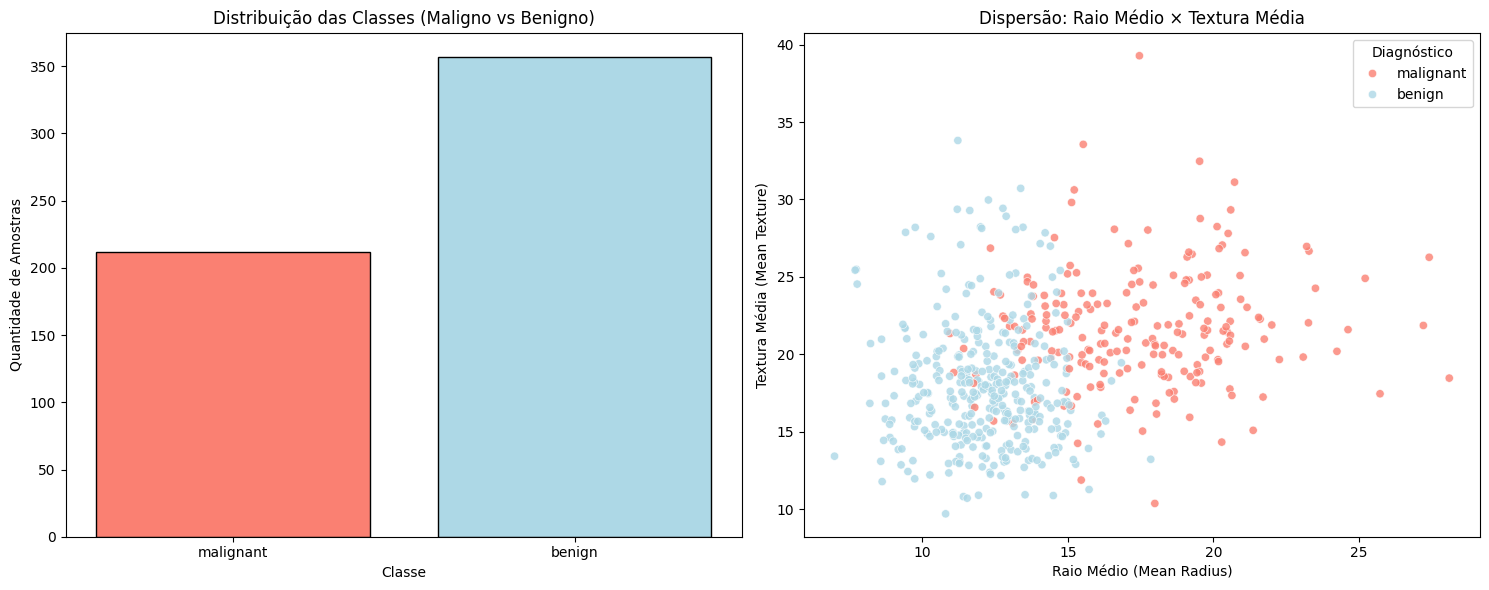

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando a área dos gráficos (1 linha, 2 colunas)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Distribuição das Classes (O que já tínhamos)
classes, contagem = np.unique(data.target, return_counts=True)
axes[0].bar(data.target_names, contagem, color=["salmon", "lightblue"], edgecolor="black")
axes[0].set_title("Distribuição das Classes (Maligno vs Benigno)", fontsize=12)
axes[0].set_xlabel("Classe")
axes[0].set_ylabel("Quantidade de Amostras")

# Gráfico 2: Dispersão de duas Features (Raio Médio x Textura Média)
# Isso mostra como os dados se separam no espaço com base nas características
sns.scatterplot(
    ax=axes[1],
    x=df["mean radius"], 
    y=df["mean texture"], 
    hue=df["target"], 
    palette=["salmon", "lightblue"],
    alpha=0.8
)
axes[1].set_title("Dispersão: Raio Médio × Textura Média", fontsize=12)
axes[1].set_xlabel("Raio Médio (Mean Radius)")
axes[1].set_ylabel("Textura Média (Mean Texture)")

# Ajustando a legenda do gráfico de dispersão
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, data.target_names, title="Diagnóstico")

plt.tight_layout()
plt.show()

4. Divisão dos Dados e Pré-processamento (StandardScaler)

O KNN funciona calculando a distância entre os dados para encontrar os vizinhos mais próximos. No dataset de Câncer de Mama, algumas features têm valores muito maiores que outras. Por exemplo, area error possui valores altos, enquanto smoothness error tem valores bem pequenos. Se os dados não forem escalonados, as features com valores maiores acabam tendo muito mais influência no cálculo da distância, e as menores quase não impactam no resultado.
Por isso, usamos o StandardScaler, que coloca todas as features na mesma escala, fazendo com que o KNN considere todas as variáveis de forma mais justa.

In [4]:
# Dividindo em treino (70%) e teste (30%)
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.3, random_state=42, stratify=data.target
)

# Aplicando o StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

5. Treinamento testando K de 1 a 20 e Gráfico de Acurácia

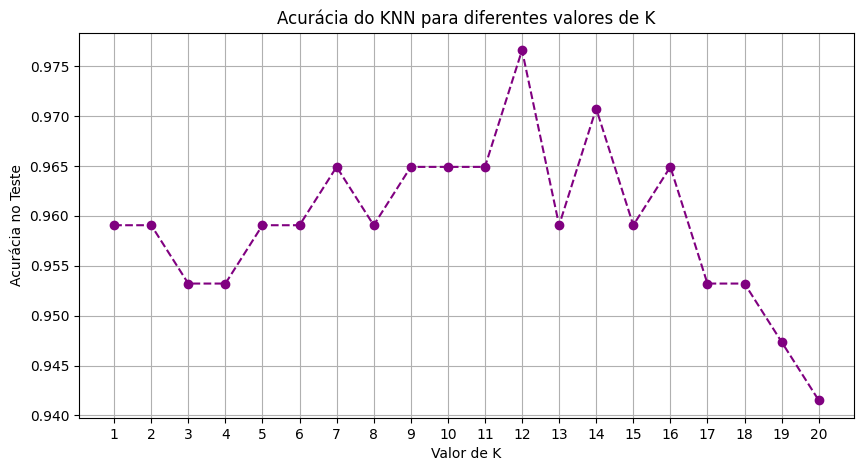

O melhor valor de K encontrado foi: 12


In [5]:
k_valores = range(1, 21)
acuracias = []

for k in k_valores:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acuracias.append(knn.score(X_test_scaled, y_test))

# Plotando o gráfico de Acurácia x K
plt.figure(figsize=(10, 5))
plt.plot(k_valores, acuracias, marker="o", linestyle="--", color="purple")
plt.title("Acurácia do KNN para diferentes valores de K")
plt.xlabel("Valor de K")
plt.ylabel("Acurácia no Teste")
plt.xticks(k_valores)
plt.grid(True)
plt.show()

# Identificando o melhor K automaticamente
melhor_k = k_valores[np.argmax(acuracias)]
print(f"O melhor valor de K encontrado foi: {melhor_k}")

A escolha do valor de K é importante no KNN porque ele define quantos vizinhos o modelo vai considerar para fazer a classificação. Após testar valores de K entre 1 e 20, o melhor resultado foi encontrado em K = 12, que apresentou a maior acurácia no teste, cerca de 97,6%.
Valores muito baixos de $K$, como 1 ou 2, podem fazer o modelo se ajustar demais aos dados de treino, causando overfitting. Já valores muito altos fazem o modelo considerar vizinhos demais, deixando a classificação mais “genérica” e reduzindo a acurácia.

Por isso, o valor K = 12 foi escolhido, pois apresentou o melhor equilíbrio e o melhor desempenho para esse conjunto de dados.

6. Modelo Final e Classification Report

In [6]:
# Treinando o modelo final
modelo_final = KNeighborsClassifier(n_neighbors=melhor_k)
modelo_final.fit(X_train_scaled, y_train)

# Predições
y_pred = modelo_final.predict(X_test_scaled)

# Exibindo o relatório de classificação
print(classification_report(y_test, y_pred, target_names=data.target_names))

              precision    recall  f1-score   support

   malignant       1.00      0.94      0.97        64
      benign       0.96      1.00      0.98       107

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



Interpretação dos Resultados

Os resultados mostram que o modelo teve um ótimo desempenho na classificação dos tumores. Para os casos malignos, a precisão foi de 1.00, ou seja, sempre que o modelo classificou um tumor como maligno, ele estava correto. Porém, o recall de 0.94 indica que alguns casos malignos reais não foram identificados.

Já para os casos benignos, o recall foi de 1.00, mostrando que o modelo conseguiu identificar corretamente todos os tumores benignos. Além disso, a precisão de 0.96 indica que quase todas as classificações de benigno estavam corretas.